In [66]:
import json
import os
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import polars as pl

QF_DISPLAY = {
    "body": "Original Query",
    "synonyms": "+ Gene Synonyms",
    "long": "+ Gene Synonyms & Products",
}

RERANK_DISPLAY = {
    "body": "Rerank (Original Query)",
    "synonyms": "Rerank (+ Gene Synonyms)",
    "long": "Rerank (+ Gene Synonyms & Products)",
    "hybrid": "Retrieval Fusion",
}

## Query-field sweep: statistical comparison (recall 200–1000)

We compare retrieval profiles (e.g. hybrid combo bm25_qf × dense_qf) using **mean recall over K ∈ {200, 300, 400, 500, 1000}** so the choice of operating point (e.g. rerank cutoff) does not dominate. Data from `scripts/public/combine_query_field_sweep_results.py` (combined sweep metrics). Stats: mean ± std across batches (train/test), rank, and optional paired test of best vs others.

In [67]:
# Two benchmarks (7d / 7e): sweep under `workflow_query_field_sweep_no_rm3_{tag}/query_field_sweep/`;
# rerank under `workflow_fixed_long_rerank_sweep_{tag}/fixed_long_rerank_sweep/` (see Vega configs).
root = Path(os.environ.get("DICTYCITE_ROOT", "../"))

BENCHMARK_CONFIGS = [
    {
        "tag": "7d",
        "sweep_dir": Path("output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7d/query_field_sweep"),
        "gold_jsonl": Path("output/dicty_gold_build/7d_dicty_gold_query_expansion_benchmark.jsonl"),
        "rerank_dir": Path("output/workflow_baseline_full_sweep/workflow_fixed_long_rerank_sweep_7d/fixed_long_rerank_sweep"),
        "run_token": "7d_dicty_gold_query_expansion_benchmark",
    },
    {
        "tag": "7e",
        "sweep_dir": Path("output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7e/query_field_sweep"),
        "gold_jsonl": Path("output/dicty_gold_build/7e_dicty_gold_query_expansion_benchmark.jsonl"),
        "rerank_dir": Path("output/workflow_baseline_full_sweep/workflow_fixed_long_rerank_sweep_7e/fixed_long_rerank_sweep"),
        "run_token": "7e_dicty_gold_query_expansion_benchmark",
    },
]


def _resolve_sweep_csv(cfg: dict) -> Path | None:
    for base in (root, Path("../")):
        d = base / cfg["sweep_dir"]
        for name in ("combined_sweep_metrics.csv", "combined_sweep_metrics_wide.csv"):
            p = d / name
            if p.is_file():
                return p
    return None

Recall (mean over K in {200..1000}), mean ± std across batches:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""HYBRID (+ Gene Synonyms & Prod…",0.949181,0.001677,1,1.930975,1
"""HYBRID (+ Gene Synonyms & Prod…",0.947943,0.001894,1,1.926633,2
"""HYBRID (+ Gene Synonyms & Prod…",0.947637,0.003241,1,1.925005,3
"""HYBRID (+ Gene Synonyms, + Gen…",0.937902,0.001146,1,1.915631,4
"""HYBRID (Original Query, + Gene…",0.931981,0.002261,1,1.904085,5
…,…,…,…,…,…
"""DENSE (+ Gene Synonyms & Produ…",0.800385,null,1,1.677916,23
"""DENSE (+ Gene Synonyms, + Gene…",0.800385,null,1,1.677916,24
"""DENSE (Original Query, Origina…",0.708792,null,1,1.518058,25



Top profiles by stage (ranked by score_r500_r1000 when available, else mean_recall):


BM25 profiles:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""BM25 (+ Gene Synonyms & Produc…",0.938869,null,1,1.902309,7
"""BM25 (+ Gene Synonyms & Produc…",0.938869,null,1,1.902309,8
"""BM25 (+ Gene Synonyms & Produc…",0.938869,null,1,1.902309,9
"""BM25 (+ Gene Synonyms, + Gene …",0.911042,null,1,1.865009,12
"""BM25 (+ Gene Synonyms, + Gene …",0.911042,null,1,1.865009,13



DENSE profiles:



...

query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.938869,1.902309
"""+ Gene Synonyms""",0.911042,1.865009
"""Original Query""",0.874038,1.798697



DENSE – 7d_dicty_gold_query_expansion_benchmark:


query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.835139,1.742747
"""+ Gene Synonyms""",0.800385,1.677916
"""Original Query""",0.708792,1.518058


MRR@K summary (7d benchmark):


7D BENCHMARK:


method,MRR@1,MRR@5,MRR@10,MRR@20,MRR@50,MRR@100,MRR@200
str,f64,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms & Prod…",0.5275,0.6136,0.6229,0.6247,0.6265,0.627,0.6272
"""Rerank (+ Gene Synonyms)""",0.5382,0.6134,0.6228,0.6256,0.6277,0.6281,0.6282
"""Rerank (Original Query)""",0.4813,0.5688,0.5765,0.5797,0.5815,0.582,0.5822
"""Retrieval Fusion""",0.444,0.5189,0.5353,0.5411,0.5433,0.5438,0.5438


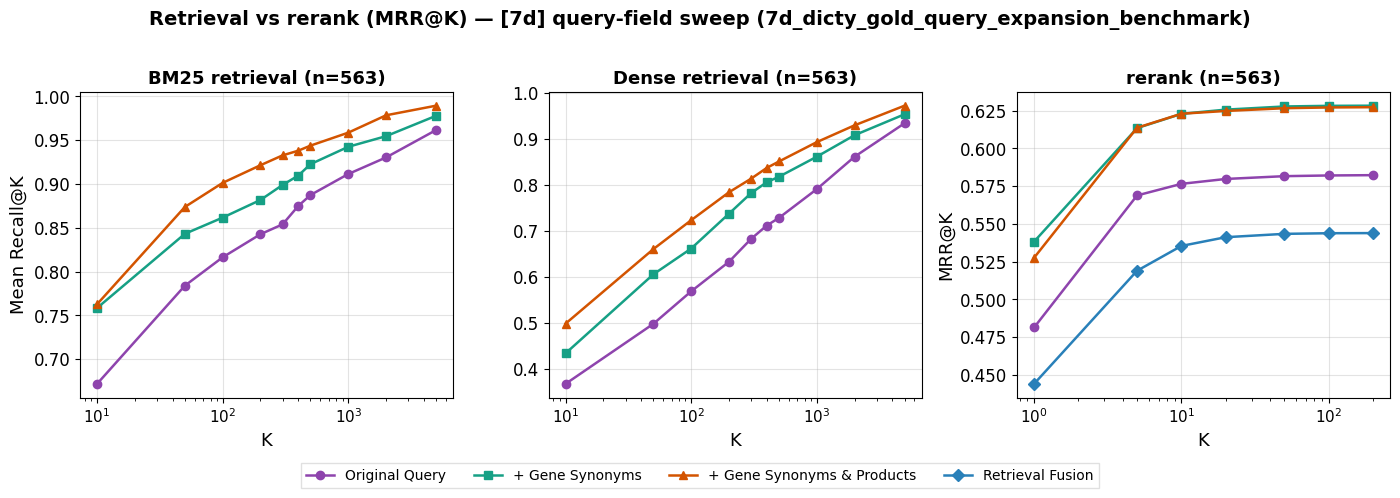

[7d] Saved 1×3 retrieval (+ rerank) figures under ../output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7d/query_field_sweep/figures
Recall (mean over K in {200..1000}), mean ± std across batches:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""HYBRID (+ Gene Synonyms & Prod…",0.989437,0.002256,1,1.988067,1
"""HYBRID (+ Gene Synonyms & Prod…",0.988498,0.001719,1,1.987676,2
"""HYBRID (+ Gene Synonyms & Prod…",0.989789,0.002553,1,1.987089,3
"""BM25 (+ Gene Synonyms & Produc…",0.98662,null,1,1.983568,4
"""BM25 (+ Gene Synonyms & Produc…",0.98662,null,1,1.983568,5
…,…,…,…,…,…
"""DENSE (+ Gene Synonyms & Produ…",0.846166,null,1,1.753912,23
"""DENSE (+ Gene Synonyms, + Gene…",0.846166,null,1,1.753912,24
"""DENSE (Original Query, Origina…",0.760485,null,1,1.601721,25



Top profiles by stage (ranked by score_r500_r1000 when available, else mean_recall):


BM25 profiles:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""BM25 (+ Gene Synonyms & Produc…",0.98662,null,1,1.983568,4
"""BM25 (+ Gene Synonyms & Produc…",0.98662,null,1,1.983568,5
"""BM25 (+ Gene Synonyms & Produc…",0.98662,null,1,1.983568,6
"""BM25 (+ Gene Synonyms, + Gene …",0.974413,null,1,1.960094,12
"""BM25 (+ Gene Synonyms, + Gene …",0.974413,null,1,1.960094,13



DENSE profiles:



...

query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.98662,1.983568
"""+ Gene Synonyms""",0.974413,1.960094
"""Original Query""",0.948279,1.921362



DENSE – 7e_dicty_gold_query_expansion_benchmark:


query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.878013,1.809077
"""+ Gene Synonyms""",0.846166,1.753912
"""Original Query""",0.760485,1.601721


MRR@K summary (7e benchmark):


7E BENCHMARK:


method,MRR@1,MRR@5,MRR@10,MRR@20,MRR@50,MRR@100,MRR@200
str,f64,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms)""",0.6315,0.707,0.715,0.7166,0.7182,0.7183,0.7184
"""Rerank (+ Gene Synonyms & Prod…",0.6221,0.7051,0.7132,0.7147,0.7159,0.7162,0.7163
"""Rerank (Original Query)""",0.5681,0.6659,0.671,0.6741,0.6753,0.6757,0.6758
"""Retrieval Fusion""",0.5023,0.5761,0.5926,0.598,0.6003,0.6006,0.6006


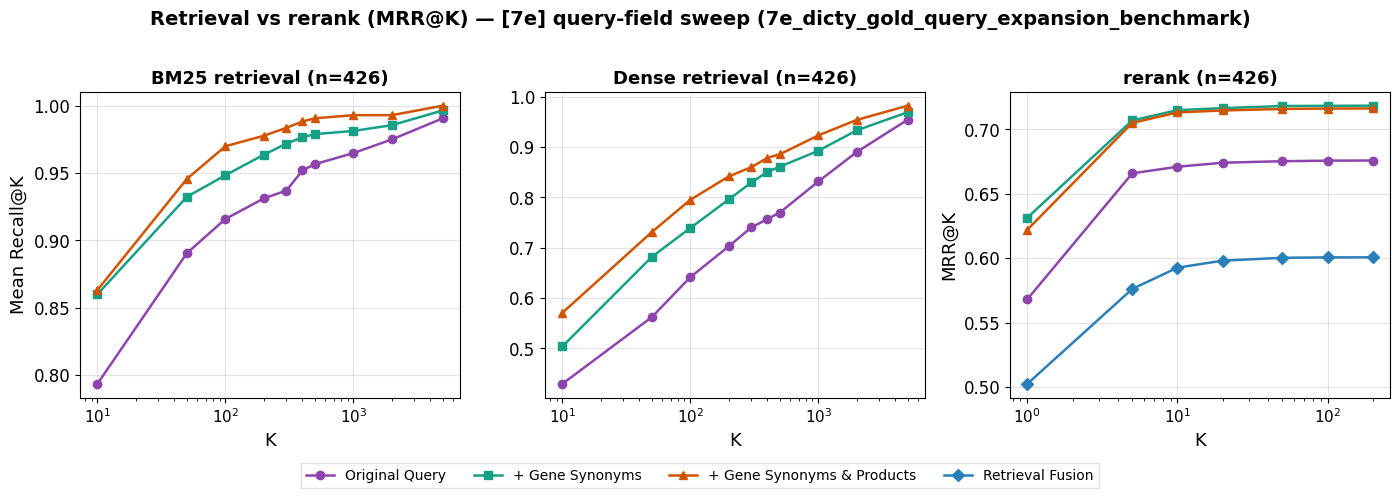

[7e] Saved 1×3 retrieval (+ rerank) figures under ../output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7e/query_field_sweep/figures


In [68]:
# Path to combined sweep metrics (from combine_query_field_sweep_results.py)

K_RANGE = [200, 300, 400, 500, 1000]  # recall@K range for "operating region" metric
MEANR_COLS = [f"MeanR@{k}" for k in K_RANGE]

for cfg in BENCHMARK_CONFIGS:
    SWEEP_CSV = _resolve_sweep_csv(cfg)
    if SWEEP_CSV is None:
        print(
            f"[{cfg['tag']}] No combined_sweep_metrics*.csv under {cfg['sweep_dir']}. "
            "Run combine_query_field_sweep_results.py for this sweep; skipping benchmark."
        )
        continue

    df = pd.read_csv(SWEEP_CSV)

    # If we loaded the wide-format combined_sweep_metrics_wide.csv, reshape to long format
    # expected by the rest of this notebook (stage + bm25_query_field + dense_query_field + MeanR@K).
    if SWEEP_CSV.name.endswith("combined_sweep_metrics_wide.csv"):
        if "query_field" not in df.columns:
            raise ValueError(f"Expected 'query_field' column in wide sweep metrics, got: {list(df.columns)}")

        rows_long = []
        methods = ["bm25", "dense", "hybrid"]
        roles = ["train", "test"]
        for _, row in df.iterrows():
            qf = str(row["query_field"]).strip()
            for method in methods:
                for role in roles:
                    rec_vals = {}
                    for k in K_RANGE:
                        wide_col = f"{role}_{method}_MeanR@{k}"
                        if wide_col in df.columns:
                            rec_vals[f"MeanR@{k}"] = float(row[wide_col])
                    if not rec_vals:
                        continue
                    rows_long.append({
                        "stage": method,
                        "bm25_query_field": qf,
                        "dense_query_field": qf,
                        "batch": role,
                        **rec_vals,
                    })
        if not rows_long:
            raise ValueError("No MeanR@K columns found in wide sweep metrics; cannot build long-format table.")
        df = pd.DataFrame(rows_long)

    # Ensure we have the recall columns (hybrid/bm25/dense may have different column sets)
    available = [c for c in MEANR_COLS if c in df.columns]
    if not available:
        raise ValueError(f"None of {MEANR_COLS} found in {SWEEP_CSV}. Columns: {list(df.columns)}")

    # Mean recall over K in [200, 300, 400, 500, 1000] per (profile, batch). Profile = stage + query fields.
    df["batch"] = df["batch"].astype(str).str.strip()
    if "stage" in df.columns:
        df["stage"] = df["stage"].astype(str).str.strip()
    if "bm25_query_field" in df.columns and "dense_query_field" in df.columns:
        df["bm25_query_field"] = df["bm25_query_field"].astype(str).str.strip()
        df["dense_query_field"] = df["dense_query_field"].astype(str).str.strip()
        df["bm25_qf_display"] = df["bm25_query_field"].map(QF_DISPLAY).fillna(df["bm25_query_field"])
        df["dense_qf_display"] = df["dense_query_field"].map(QF_DISPLAY).fillna(df["dense_query_field"])
        df["profile"] = df["stage"].str.upper() + " (" + df["bm25_qf_display"] + ", " + df["dense_qf_display"] + ")"
    else:
        df["profile"] = df.get("stage", df.get("method", "unknown"))

    # Operating-region mean recall across K
    df["mean_recall_200_1000"] = df[available].mean(axis=1)

    # Simple scoring profile: MeanR@500 + MeanR@1000 (when available)
    score_cols = [c for c in ["MeanR@500", "MeanR@1000"] if c in df.columns]
    if score_cols:
        df["score_r500_r1000"] = df[score_cols].sum(axis=1)

    # Per-profile summary: mean/std across batches
    agg_dict = {
        "mean_recall_200_1000": ["mean", "std"],
        "batch": ["nunique"],
    }
    if "score_r500_r1000" in df.columns:
        agg_dict["score_r500_r1000"] = ["mean"]

    summary = df.groupby("profile").agg(agg_dict)
    summary.columns = [
        "mean_recall" if c == ("mean_recall_200_1000", "mean") else
        "std_recall" if c == ("mean_recall_200_1000", "std") else
        "n_batches" if c == ("batch", "nunique") else
        "score_r500_r1000" if c == ("score_r500_r1000", "mean") else "_".join(map(str, c))
        for c in summary.columns
    ]
    summary = summary.reset_index()

    # Rank by score profile when available, otherwise by mean_recall
    if "score_r500_r1000" in summary.columns:
        summary = summary.sort_values("score_r500_r1000", ascending=False).reset_index(drop=True)
    else:
        summary = summary.sort_values("mean_recall", ascending=False).reset_index(drop=True)
    summary["rank"] = range(1, len(summary) + 1)

    print("Recall (mean over K in {200..1000}), mean ± std across batches:\n")
    display(pl.from_pandas(summary))

    # Per-stage top profiles for quick inspection (BM25 and Dense)
    print("\nTop profiles by stage (ranked by score_r500_r1000 when available, else mean_recall):\n")

    for stage in ["bm25", "dense"]:
        # Filter profiles belonging to this stage (profile starts with STAGE in upper-case)
        stage_profiles = summary[summary["profile"].str.upper().str.startswith(stage.upper())]
        if stage_profiles.empty:
            continue
        print(f"\n{stage.upper()} profiles:\n")
        display(pl.from_pandas(stage_profiles.head(5)))


    # Compact per-stage summary: for each batch (train/test), three scores per query-field
    # Uses score profile: MeanR@500 + MeanR@1000 when available.

    batches = sorted(df["batch"].astype(str).str.strip().unique().tolist())

    print("Per-stage summary by batch (BM25 and DENSE):\n")

    for stage in ["bm25", "dense"]:
        stage_df = df[df["stage"] == stage].copy()
        if stage_df.empty:
            continue

        # Stage-specific query field
        if stage == "bm25":
            stage_df["qf"] = stage_df["bm25_query_field"].astype(str).str.strip()
        else:
            stage_df["qf"] = stage_df["dense_query_field"].astype(str).str.strip()
        stage_df["qf_display"] = stage_df["qf"].map(QF_DISPLAY).fillna(stage_df["qf"])

        # Score profile: MeanR@500 + MeanR@1000 (when available)
        score_cols = [c for c in ["MeanR@500", "MeanR@1000"] if c in stage_df.columns]
        if score_cols:
            stage_df["score_r500_r1000"] = stage_df[score_cols].sum(axis=1)

        stage_df["batch"] = stage_df["batch"].astype(str).str.strip()

        for batch in batches:
            sub = stage_df[stage_df["batch"] == batch]
            if sub.empty:
                continue

            agg = {
                "mean_recall_200_1000": "mean",
            }
            if "score_r500_r1000" in sub.columns:
                agg["score_r500_r1000"] = "mean"

            summary_stage = (
                sub.groupby("qf_display").agg(agg).reset_index()
            )

            # Rename columns for display
            cols = {"qf_display": "query_field", "mean_recall_200_1000": "mean_recall"}
            summary_stage = summary_stage.rename(columns=cols)

            # Sort by score if present, otherwise by mean_recall
            if "score_r500_r1000" in summary_stage.columns:
                summary_stage = summary_stage.sort_values("score_r500_r1000", ascending=False)
            else:
                summary_stage = summary_stage.sort_values("mean_recall", ascending=False)

            print(f"\n{stage.upper()} – {batch}:")
            display(pl.from_pandas(summary_stage))

    # Plot recall curves per batch: BM25 | Dense in 1×2 panels. X-axis is log-scaled (K).
    # n in subtitles only when metrics.csv / combined CSV supplies a consistent `n_queries`.

    def _n_queries_if_known(subset: pd.DataFrame, batch: str) -> int | None:
        """Return evaluation query count only from `n_queries` when present and unique per batch."""
        sub = subset[subset["batch"].astype(str).str.strip() == str(batch).strip()]
        if sub.empty or "n_queries" not in sub.columns:
            return None
        n = pd.to_numeric(sub["n_queries"], errors="coerce").dropna()
        if n.empty:
            return None
        uniq = n.unique()
        if len(uniq) != 1:
            return None
        return int(uniq[0])


    # Recall columns + K ordering
    recall_cols = sorted(
        [c for c in df.columns if c.startswith("MeanR@")],
        key=lambda c: int(c.split("@")[1]),
    )
    if not recall_cols:
        raise ValueError(f"No MeanR@K columns found in sweep metrics: {list(df.columns)}")
    ks = [int(c.split("@")[1]) for c in recall_cols]

    plot_df = df.copy()
    plot_df["batch"] = plot_df["batch"].astype(str).str.strip()
    plot_df["stage"] = plot_df["stage"].astype(str).str.strip()
    plot_df["combo"] = plot_df.get("combo", "").astype(str).str.strip()
    plot_df["bm25_qf"] = plot_df["bm25_query_field"].astype(str).str.strip()
    plot_df["dense_qf"] = plot_df["dense_query_field"].astype(str).str.strip()

    plot_df["bm25_qf_disp"] = plot_df["bm25_qf"].map(QF_DISPLAY).fillna(plot_df["bm25_qf"])
    plot_df["dense_qf_disp"] = plot_df["dense_qf"].map(QF_DISPLAY).fillna(plot_df["dense_qf"])

    batches = plot_df["batch"].unique().tolist()
    qf_order = ["body", "synonyms", "long"]

    # Distinct from notebooks/report.py tab-blues/oranges/greens
    QF_COLORS = {"body": "#8e44ad", "synonyms": "#16a085", "long": "#d35400"}
    QF_MARKERS = {"body": "o", "synonyms": "s", "long": "^"}

    figures_dir = root / cfg["sweep_dir"] / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    _rc_plot = {
        "figure.figsize": (13.5, 4.8),
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 12,
    }

    # --- Rerank MRR@K: load before combined figure ---
    RERANK_SWEEP_DIR = root / cfg["rerank_dir"]

    RERANK_DIRS = {
        "body": RERANK_SWEEP_DIR / "rerank_body",
        "synonyms": RERANK_SWEEP_DIR / "rerank_synonyms",
        "long": RERANK_SWEEP_DIR / "rerank_long",
        "hybrid": RERANK_SWEEP_DIR / "retrieval" / "fusion",
    }

    KS_MAP = [1, 5, 10, 20, 50, 100, 200]


    def load_gold_jsonl(path: Path) -> dict:
        """Load gold from JSONL: qid -> list of relevant docnos (PMIDs as strings)."""
        gold = {}
        with open(path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                q = json.loads(line)
                qid = str(q.get("query_id", q.get("id", "")))
                if not qid:
                    continue
                pmids = []
                for doc in q.get("documents", []):
                    if isinstance(doc, str) and doc.startswith("http"):
                        pmids.append(doc.split("/")[-1])
                    elif doc:
                        pmids.append(str(doc))
                for d in q.get("docs", []):
                    if isinstance(d, dict) and d.get("pmid"):
                        pmids.append(str(d["pmid"]))
                gold[qid] = list(set(pmids))
        return gold


    def load_run(path):
        """Load run TSV: qid -> ranked list of docnos (handles multiple column orders)."""
        run = {}
        header = None
        with open(path) as f:
            for line in f:
                parts = line.strip().split("\t")
                if parts[0] == "qid":
                    header = parts
                    continue
                if len(parts) < 3:
                    continue
                if header:
                    qid_idx = header.index("qid") if "qid" in header else 0
                    docno_idx = header.index("docno") if "docno" in header else 1
                else:
                    qid_idx, docno_idx = 0, 1
                qid, docno = parts[qid_idx], parts[docno_idx]
                run.setdefault(qid, []).append(docno)
        return run


    def mrr_at_k(ranked, relset, k):
        """Reciprocal rank of first relevant doc in top-k (0 if none)."""
        for i, docno in enumerate(ranked[:k], start=1):
            if docno in relset:
                return 1.0 / i
        return 0.0


    def mean_mrr_at_k(gold, run, k):
        scores = []
        for qid, relset in gold.items():
            ranked = run.get(qid, [])
            scores.append(mrr_at_k(ranked, set(relset), k))
        return sum(scores) / len(scores) if scores else 0.0


    def _ylim_from_vals(vals, hi_clip):
        if not vals:
            return 0.5, hi_clip
        lo, hi = min(vals), max(vals)
        pad = (hi - lo) * 0.05 if hi > lo else 0.02
        return max(0.0, lo - pad), min(hi_clip, hi + pad)


    BENCHMARK_TOKEN = cfg["run_token"]
    GOLD_JSONL = root / cfg["gold_jsonl"]

    gold_bench = load_gold_jsonl(GOLD_JSONL)
    mrr_curves = defaultdict(dict)

    for method_key, rdir in RERANK_DIRS.items():
        runs_dir = rdir / "runs"
        if not runs_dir.is_dir():
            print(f"[{cfg['tag']}] Skipping rerank method {method_key}: no runs dir")
            continue
        for run_file in runs_dir.glob("*.tsv"):
            run_name = run_file.stem
            if BENCHMARK_TOKEN not in run_name:
                continue
            run = load_run(run_file)
            mrr_vals = [mean_mrr_at_k(gold_bench, run, k) for k in KS_MAP]
            mrr_curves["benchmark"][RERANK_DISPLAY[method_key]] = mrr_vals

    roles_present = [r for r in sorted(mrr_curves.keys()) if mrr_curves[r]]
    has_rerank = bool(roles_present and mrr_curves.get("benchmark"))

    _rerank_qf_colors = {**QF_COLORS, "hybrid": "#2980b9"}
    _rerank_qf_markers = {**QF_MARKERS, "hybrid": "D"}
    _display_to_qf = {v: k for k, v in RERANK_DISPLAY.items()}
    method_order_rr = list(RERANK_DISPLAY.values())

    print(f"MRR@K summary ({cfg['tag']} benchmark):\n")
    for role in roles_present:
        rows = []
        for method, vals in mrr_curves[role].items():
            row = {"method": method}
            for k, v in zip(KS_MAP, vals):
                row[f"MRR@{k}"] = round(v, 4)
            rows.append(row)
        if rows:
            df_summary = pd.DataFrame(rows)
            df_summary = df_summary.sort_values("MRR@10", ascending=False).reset_index(drop=True)
            label = f"{cfg['tag']} benchmark" if role == "benchmark" else role
            print(f"\n{label.upper()}:")
            display(pl.from_pandas(df_summary))

    if not roles_present:
        print(
            f"\n[{cfg['tag']}] No rerank run TSVs matched '{BENCHMARK_TOKEN}' "
            "— third panel skipped until runs exist.\n"
        )


    def _shared_legend_handles(include_hybrid: bool):
        """Match line styles across retrieval + rerank panels."""
        out = []
        for q in ["body", "synonyms", "long"]:
            out.append(
                Line2D(
                    [0],
                    [0],
                    color=QF_COLORS[q],
                    marker=QF_MARKERS[q],
                    linestyle="-",
                    linewidth=1.8,
                    markersize=6,
                    label=QF_DISPLAY[q],
                )
            )
        if include_hybrid:
            out.append(
                Line2D(
                    [0],
                    [0],
                    color=_rerank_qf_colors["hybrid"],
                    marker=_rerank_qf_markers["hybrid"],
                    linestyle="-",
                    linewidth=1.8,
                    markersize=6,
                    label=RERANK_DISPLAY["hybrid"],
                )
            )
        return out


    n_queries_gold = len(gold_bench)

    with plt.rc_context(_rc_plot):
        for batch in batches:
            subset = plot_df[plot_df["batch"] == batch]
            if subset.empty:
                continue
            n_known = _n_queries_if_known(subset, batch)
            n_suffix = f" (n={n_known})" if n_known is not None else ""

            vals_bm25 = []
            for qf in qf_order:
                rows = subset[(subset["stage"] == "bm25") & (subset["bm25_qf"] == qf)]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                vals_bm25.extend(float(row[c]) for c in recall_cols)
            y0_lo, y0_hi = _ylim_from_vals(vals_bm25, 1.02)

            vals_dense = []
            for qf in qf_order:
                rows = subset[(subset["stage"] == "dense") & (subset["dense_qf"] == qf)]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                vals_dense.extend(float(row[c]) for c in recall_cols)
            y1_lo, y1_hi = _ylim_from_vals(vals_dense, 1.02)

            ncols = 3 if has_rerank else 2
            fig_w = 4.7 * ncols
            fig, axes = plt.subplots(1, ncols, figsize=(fig_w, 4.85))

            if ncols == 1:
                axes = [axes]
            else:
                axes = list(axes)

            # BM25 retrieval (own y-scale)
            ax0 = axes[0]
            for qf in qf_order:
                rows = subset[(subset["stage"] == "bm25") & (subset["bm25_qf"] == qf)]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                vals = [float(row[c]) for c in recall_cols]
                ax0.plot(
                    ks,
                    vals,
                    marker=QF_MARKERS.get(qf, "o"),
                    color=QF_COLORS.get(qf, "#333333"),
                    linewidth=1.8,
                    markersize=6,
                )
            ax0.set_title(f"BM25 retrieval{n_suffix}", fontsize=13, fontweight="bold")
            ax0.set_ylim(y0_lo, y0_hi)
            ax0.set_xlabel("K")
            ax0.set_xscale("log")
            ax0.set_ylabel("Mean Recall@K")
            ax0.grid(True, axis="y", alpha=0.35)
            ax0.grid(True, axis="x", alpha=0.35)

            # Dense retrieval (own y-scale)
            ax1 = axes[1]
            for qf in qf_order:
                rows = subset[(subset["stage"] == "dense") & (subset["dense_qf"] == qf)]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                vals = [float(row[c]) for c in recall_cols]
                ax1.plot(
                    ks,
                    vals,
                    marker=QF_MARKERS.get(qf, "o"),
                    color=QF_COLORS.get(qf, "#333333"),
                    linewidth=1.8,
                    markersize=6,
                )
            ax1.set_title(f"Dense retrieval{n_suffix}", fontsize=13, fontweight="bold")
            ax1.set_ylim(y1_lo, y1_hi)
            ax1.set_xlabel("K")
            ax1.set_xscale("log")
            ax1.set_ylabel("")
            ax1.grid(True, axis="y", alpha=0.35)
            ax1.grid(True, axis="x", alpha=0.35)

            if has_rerank:
                ax2 = axes[2]
                role_key = "benchmark"
                for method in method_order_rr:
                    if method not in mrr_curves[role_key]:
                        continue
                    qf = _display_to_qf.get(method, method)
                    ax2.plot(
                        KS_MAP,
                        mrr_curves[role_key][method],
                        marker=_rerank_qf_markers.get(qf, "o"),
                        color=_rerank_qf_colors.get(qf, "#333333"),
                        linewidth=1.8,
                        markersize=6,
                    )
                mrr_flat = [v for vals in mrr_curves[role_key].values() for v in vals]
                if mrr_flat:
                    _lo, _hi = _ylim_from_vals(mrr_flat, 1.0)
                    ax2.set_ylim(_lo, _hi)
                ax2.set_title(f"rerank (n={n_queries_gold})", fontsize=13, fontweight="bold")
                ax2.set_xlabel("K")
                ax2.set_xscale("log")
                ax2.set_ylabel("MRR@K")
                ax2.grid(True, axis="y", alpha=0.35)
                ax2.grid(True, axis="x", alpha=0.35)

            leg_handles = _shared_legend_handles(include_hybrid=has_rerank)
            fig.legend(
                handles=leg_handles,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.1),
                ncol=4 if has_rerank else 3,
                fontsize=10,
                frameon=True,
                fancybox=False,
                edgecolor="0.85",
            )
            fig.suptitle(
                f"Retrieval vs rerank (MRR@K) — [{cfg['tag']}] query-field sweep ({batch})",
                fontsize=14,
                fontweight="bold",
                y=1.02,
            )
            plt.tight_layout()
            fig.subplots_adjust(bottom=0.22)

            safe_name = re.sub(r"[^\w\-]", "_", str(batch))
            out_path = figures_dir / f"retrieval_rerank_row_{cfg['tag']}_{safe_name}.png"
            fig.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.show()
            plt.close(fig)

    print(
        f"[{cfg['tag']}] Saved 1×{'3' if has_rerank else '2'} retrieval (+ rerank) figures under {figures_dir}"
    )

Rerank MRR@K numbers are summarized above per benchmark tag (`7d` / `7e`): runs live under `workflow_fixed_long_rerank_sweep_{tag}/fixed_long_rerank_sweep/` (`rerank_body`, …).